# Task 1: Financial News Exploratory Data Analysis

This notebook develops the evidence base for the later technical-indicator and sentiment-correlation work. It covers headline descriptive statistics, publisher concentration, publisher-domain patterns, news-volume time series, publishing-hour behavior, TF-IDF keywords, recurring phrases, and interpretable market themes.

In [23]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loading import load_news
from src.eda import (
    add_headline_length,
    headline_length_stats,
    headline_theme_counts,
    news_volume_spikes,
    publication_frequency,
    publisher_coverage_summary,
    publisher_domains,
    publishing_hour_distribution,
    recurring_phrases,
    top_keywords,
    top_publishers,
)
from src.visualization import plot_news_volume, plot_top_publishers, save_current_figure

sns.set_theme(style='whitegrid')
RAW = PROJECT_ROOT / 'data' / 'raw'
FIGURES = PROJECT_ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## Load Data

Place the FNSPID news dataset at `data/raw/fnspid_news.csv`. Expected columns are `headline`, `url`, `publisher`, `date`, and `stock`.

In [24]:
NEWS_FILE = RAW / 'fnspid_news.csv'
if not NEWS_FILE.exists():
    raise FileNotFoundError(f'Missing {NEWS_FILE}. Add the FNSPID news CSV before running Task 1 EDA.')

news = load_news(NEWS_FILE)
news.head()

,headline,url,publisher,date,stock
0,Apple shares hit new high,https://finance.example.com/aapl-high,FinanceNews,2026-05-01 09:30:00+00:00,AAPL
1,Tesla beats earnings expectations,https://finance.example.com/tsla-earnings,MarketWatch,2026-05-02 16:00:00+00:00,TSLA
2,Amazon announces stock split,https://finance.example.com/amzn-split,BusinessWire,2026-05-03 08:00:00+00:00,AMZN
3,Microsoft acquires AI startup,https://finance.example.com/msft-acquisition,Reuters,2026-05-04 12:00:00+00:00,MSFT
4,Google faces antitrust probe,https://finance.example.com/googl-antitrust,WSJ,2026-05-05 14:00:00+00:00,GOOGL


In [25]:
print(f'Rows: {len(news):,}')
print(f'Stocks covered: {news["stock"].nunique():,}')
print(f'Publishers: {news["publisher"].nunique():,}')
print(f'Date range: {news["date"].min()} to {news["date"].max()}')
news.info()

Rows: 5
Stocks covered: 5
Publishers: 5
Date range: 2026-05-01 09:30:00+00:00 to 2026-05-05 14:00:00+00:00
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   headline   5 non-null      str                
 1   url        5 non-null      str                
 2   publisher  5 non-null      str                
 3   date       5 non-null      datetime64[us, UTC]
 4   stock      5 non-null      str                
dtypes: datetime64[us, UTC](1), str(4)
memory usage: 332.0 bytes


## Descriptive Statistics: Headline Length

Headline length helps reveal whether the dataset is made of short alerts, longer editorial headlines, or a mix. This matters because very short headlines may carry less sentiment context while longer headlines may contain richer event information.

In [26]:
news_len = add_headline_length(news)
headline_summary = headline_length_stats(news).to_frame('headline_characters')
headline_summary

,headline_characters
count,5.000000
mean,28.600000
std,2.880972
min,25.000000
25%,28.000000
50%,28.000000
75%,29.000000
max,33.000000


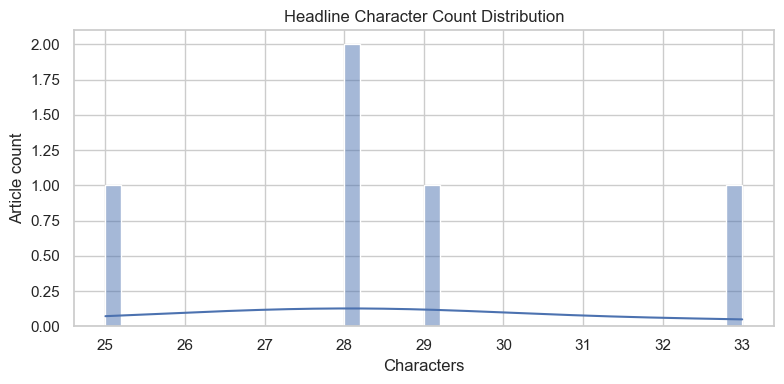

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(news_len['headline_length'], bins=40, kde=True, ax=ax)
ax.set_title('Headline Character Count Distribution')
ax.set_xlabel('Characters')
ax.set_ylabel('Article count')
save_current_figure(FIGURES / 'headline_length_distribution.png')
plt.show()

#### Figure 1: Headline Length Distribution
The histogram below shows the distribution of headline character counts in the news dataset. Longer headlines often provide richer context for sentiment analysis, while very short headlines may be less informative.

In [28]:
news_len.nlargest(10, 'headline_length')[['date', 'stock', 'publisher', 'headline_length', 'headline']]

,date,stock,publisher,headline_length,headline
1,2026-05-02 16:00:00+00:00,TSLA,MarketWatch,33,Tesla beats earnings expectations
3,2026-05-04 12:00:00+00:00,MSFT,Reuters,29,Microsoft acquires AI startup
2,2026-05-03 08:00:00+00:00,AMZN,BusinessWire,28,Amazon announces stock split
4,2026-05-05 14:00:00+00:00,GOOGL,WSJ,28,Google faces antitrust probe
0,2026-05-01 09:30:00+00:00,AAPL,FinanceNews,25,Apple shares hit new high


## Publisher Analysis

This section identifies the most active publishers and whether publisher names include email domains. Heavy publisher concentration can influence the tone and topic mix of the sentiment dataset.

In [29]:
publisher_counts = top_publishers(news, 15)
publisher_counts.to_frame('article_count')

,article_count
publisher,
FinanceNews,1
MarketWatch,1
BusinessWire,1
Reuters,1
WSJ,1


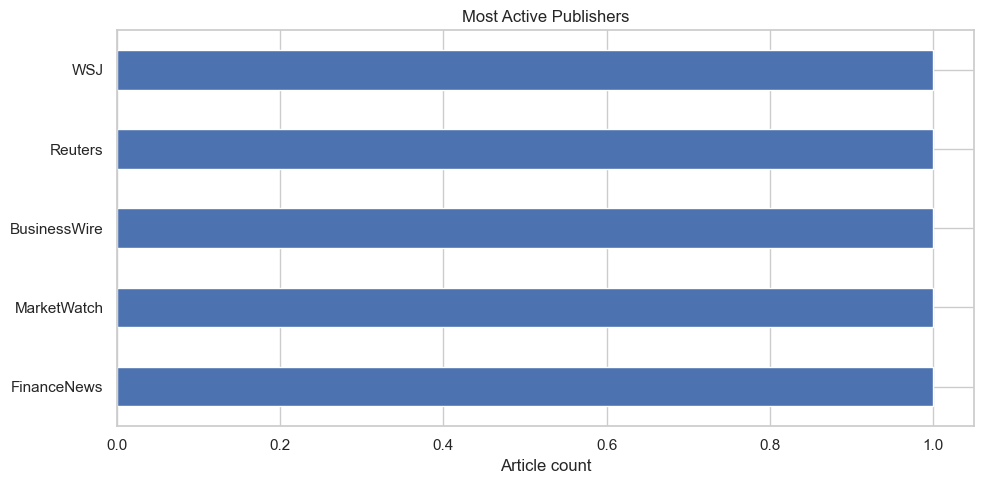

In [30]:
fig, ax = plot_top_publishers(publisher_counts)
save_current_figure(FIGURES / 'top_publishers.png')
plt.show()

#### Figure 2: Top Publishers by Article Count
This bar chart displays the most active publishers in the dataset. Publisher concentration can influence the overall sentiment and topic mix, so it is important to identify dominant sources.

In [31]:
publisher_coverage_summary(news, 10)

,publisher,article_count,unique_stocks,first_date,last_date
0,BusinessWire,1,1,2026-05-03,2026-05-03
1,FinanceNews,1,1,2026-05-01,2026-05-01
2,MarketWatch,1,1,2026-05-02,2026-05-02
3,Reuters,1,1,2026-05-04,2026-05-04
4,WSJ,1,1,2026-05-05,2026-05-05


In [32]:
publisher_domains(news).head(20).to_frame('article_count')

,article_count
publisher,
unknown,5


## Publication Timing and Annotated Volume Spikes

Daily news volume shows whether coverage is steady or clustered around high-attention periods. Spikes are flagged with z-scores so unusually active periods can be reviewed against known earnings, macro, regulatory, or company-specific events.

In [33]:
daily_volume = publication_frequency(news, 'D')
spikes = news_volume_spikes(news, 'D', z_threshold=2.0)
spikes.head(15)

,period,article_count,z_score


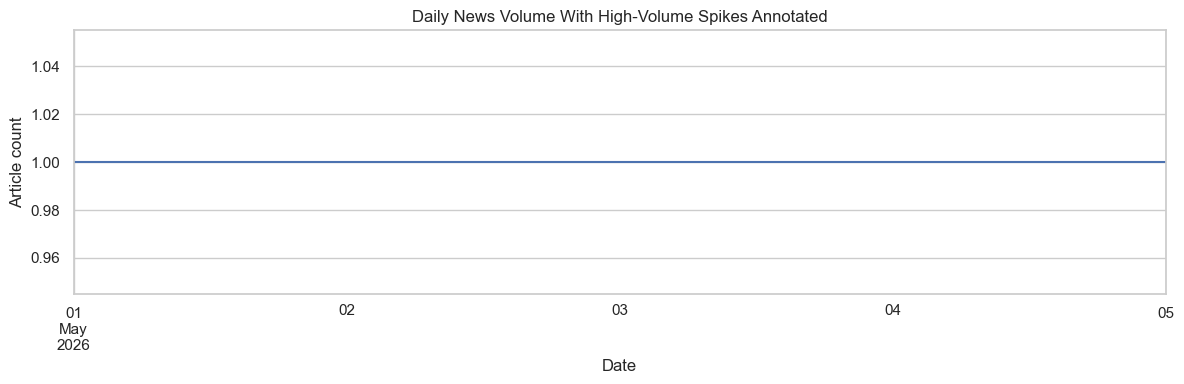

In [34]:
fig, ax = plot_news_volume(daily_volume)
for _, row in spikes.head(8).iterrows():
    ax.annotate(
        str(pd.to_datetime(row['period']).date()),
        xy=(row['period'], row['article_count']),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        rotation=45,
    )
ax.set_title('Daily News Volume With High-Volume Spikes Annotated')
save_current_figure(FIGURES / 'daily_news_volume_annotated.png')
plt.show()

#### Figure 3: Daily News Volume with Annotated Spikes
The time series plot below shows daily news volume, with high-volume spikes annotated. These spikes often correspond to major market events, earnings releases, or other impactful news periods.

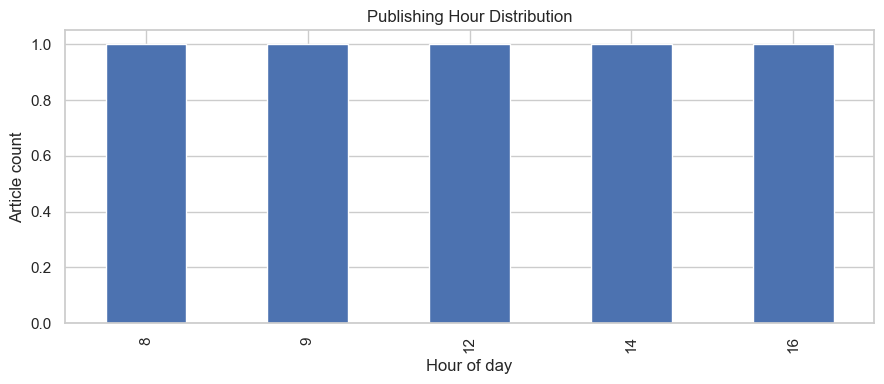

date,8,9,12,14,16
article_count,1,1,1,1,1


In [35]:
hourly = publishing_hour_distribution(news)
fig, ax = plt.subplots(figsize=(9, 4))
hourly.plot(kind='bar', ax=ax)
ax.set_title('Publishing Hour Distribution')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Article count')
save_current_figure(FIGURES / 'publishing_hours.png')
plt.show()
hourly.to_frame('article_count').T

#### Figure 4: Publishing Hour Distribution
This bar chart shows the distribution of article publication times by hour of day. Understanding when news is released can help align sentiment signals with trading activity.

## Keyword, Phrase, and Topic Signals

TF-IDF highlights distinctive words or short phrases, while phrase counts show repeated headline templates. Theme counts translate keywords into business-readable categories such as earnings, ratings, price movement, corporate actions, and regulatory/legal events.

In [36]:
keywords = top_keywords(news, 30)
keywords

ValueError: After pruning, no terms remain. Try a lower min_df or a higher max_df.

In [ ]:
phrases = recurring_phrases(news, 30)
phrases

In [ ]:
themes = headline_theme_counts(news)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=themes, y='theme', x='article_count', ax=ax, color='steelblue')
ax.set_title('Headline Theme Counts')
ax.set_xlabel('Article count')
ax.set_ylabel('')
save_current_figure(FIGURES / 'headline_theme_counts.png')
plt.show()
themes

#### Figure 5: Headline Theme Counts
This bar chart summarizes the most common headline themes, such as earnings, ratings, price movement, and regulatory events. These themes help identify the types of news most prevalent in the dataset.

## Investment-Relevant EDA Takeaways

After running the notebook, use the tables and annotated plots above to write the strongest observations for the final report:

- **Publisher concentration:** If a few publishers dominate coverage, sentiment signals may partly reflect those publishers' editorial style rather than broad market opinion.
- **Headline length:** Short alert-style headlines may be noisy for sentiment; longer headlines often include richer event context such as earnings, ratings, or regulatory decisions.
- **Volume spikes:** Annotated spikes identify dates where abnormal news attention may coincide with earnings cycles, analyst updates, macro shocks, or company-specific events. These dates are useful candidates for later return and sentiment-event checks.
- **Publishing hour pattern:** Concentration before or near market hours can affect whether sentiment should be aligned to the same trading day or the next trading day.
- **Topics/themes:** Earnings, analyst ratings, price movement, corporate actions, and regulatory/legal themes should be interpreted separately because they may have different price-impact horizons.

These EDA findings connect directly to the investment thesis: news sentiment is more useful when it is filtered by publisher reliability, event theme, publication timing, and confirmation from technical indicators rather than treated as a single raw headline score.